<a href="https://colab.research.google.com/github/UttamPachauri/Customer-Churn-Project/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Telco_customer_churn.xlsx")
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [3]:
df.shape

(7043, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


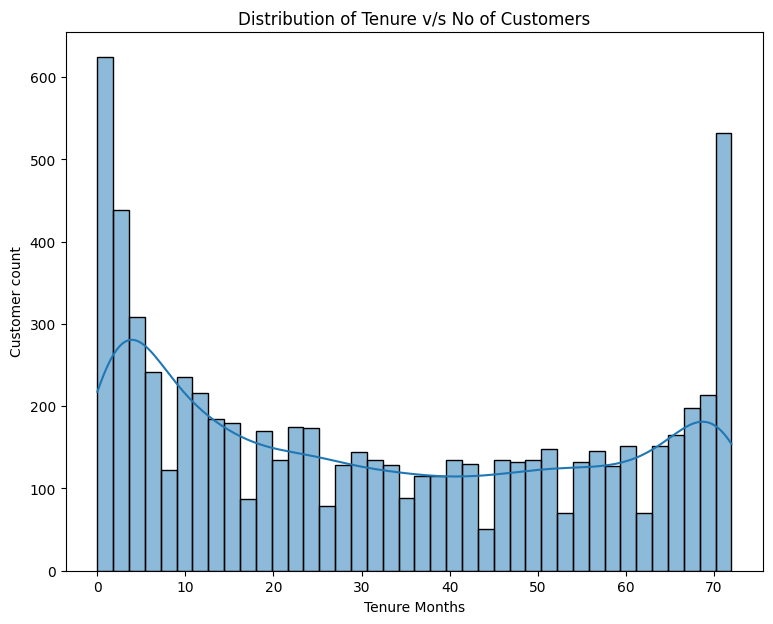

In [6]:
plt.figure( figsize = (9, 7) ) #height and width
sns.histplot(df['Tenure Months'], bins = 40, kde = True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure v/s No of Customers')
plt.show()

In [7]:
df['Tenure Months'].min()

0

In [8]:
df['Tenure Months'].max()

72

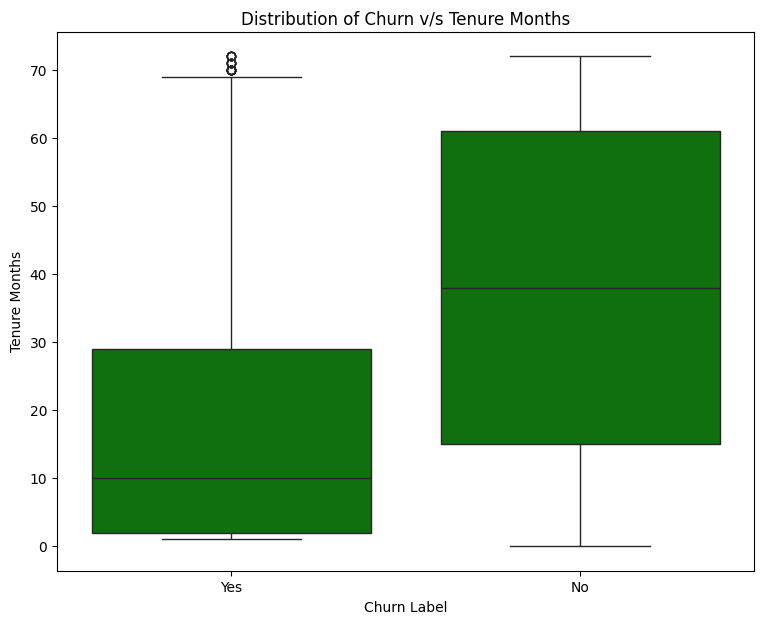

In [9]:
plt.figure( figsize = (9, 7) ) #height and width
sns.boxplot( x = 'Churn Label', y = 'Tenure Months', data = df, color='green')
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Distribution of Churn v/s Tenure Months')
plt.show()

In [10]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [11]:
df[df['Churn Label'] == 'Yes']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,1699-HPSBG,1,United States,California,Palm Springs,92264,"33.745746, -116.514215",33.745746,-116.514215,Male,...,One year,Yes,Electronic check,59.80,727.8,Yes,1,69,4581,Competitor offered higher download speeds
1865,8775-CEBBJ,1,United States,California,Seeley,92273,"32.790282, -115.689559",32.790282,-115.689559,Female,...,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes,1,87,2029,Competitor offered higher download speeds
1866,6894-LFHLY,1,United States,California,Vidal,92280,"34.264124, -114.717964",34.264124,-114.717964,Male,...,Month-to-month,Yes,Electronic check,75.75,75.75,Yes,1,97,5571,Competitor offered higher download speeds
1867,0639-TSIQW,1,United States,California,White Water,92282,"33.972293, -116.654195",33.972293,-116.654195,Female,...,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes,1,70,5620,Competitor offered more data


In [12]:
df['Monthly Charges'].max()

118.75

In [13]:
df['Monthly Charges'].min()

18.25

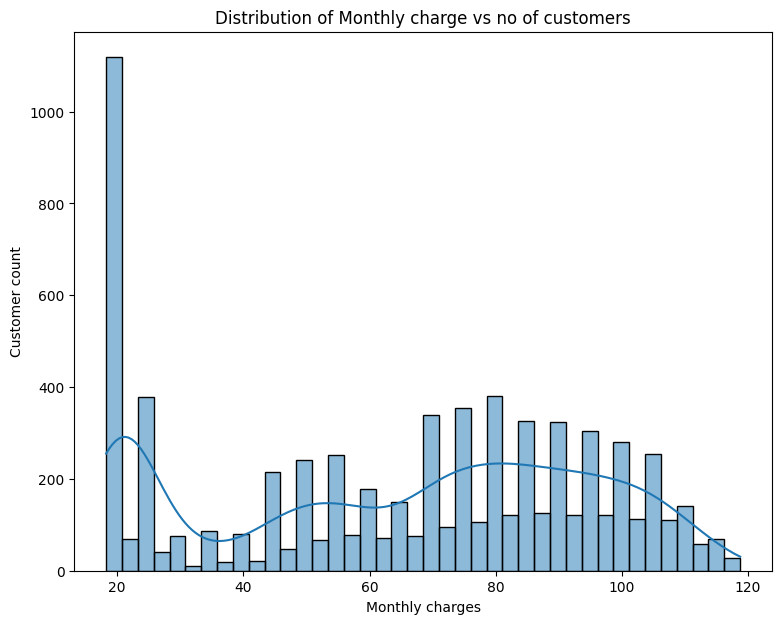

In [14]:
plt.figure(figsize=(9,7))
sns.histplot(df['Monthly Charges'], bins=40, kde=True)
plt.xlabel('Monthly charges')
plt.ylabel('Customer count')
plt.title('Distribution of Monthly charge vs no of customers')
plt.show()

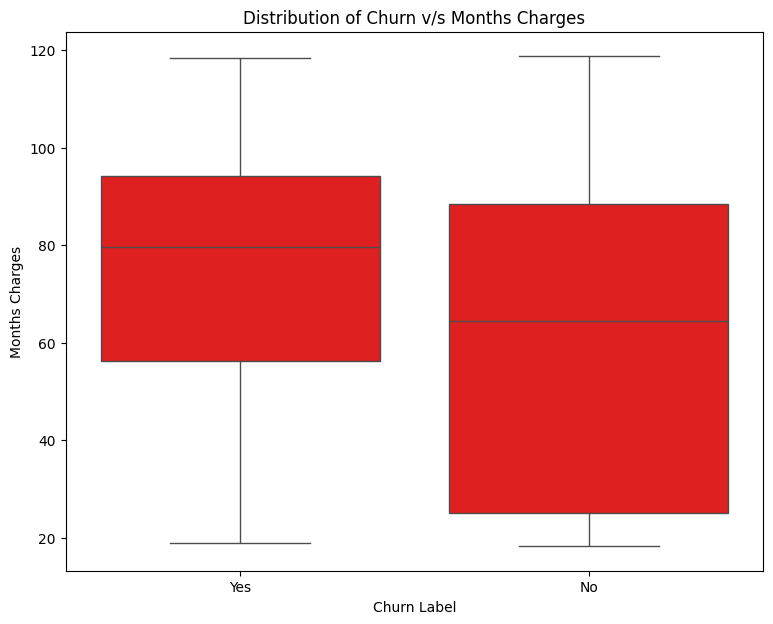

In [15]:
plt.figure( figsize = (9, 7) ) #height and width
sns.boxplot( x = 'Churn Label', y = 'Monthly Charges', data = df, color='red')
plt.xlabel('Churn Label')
plt.ylabel('Months Charges')
plt.title('Distribution of Churn v/s Months Charges')
plt.show()

In [16]:
df[df['Churn Label'] == 'Yes']['Monthly Charges'].quantile([0.25, 0.5, 0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [17]:
df[df['Churn Label'] == 'No']['Monthly Charges'].quantile([0.25, 0.5, 0.7])

,Monthly Charges
0.25,25.100
0.50,64.425
0.70,83.805


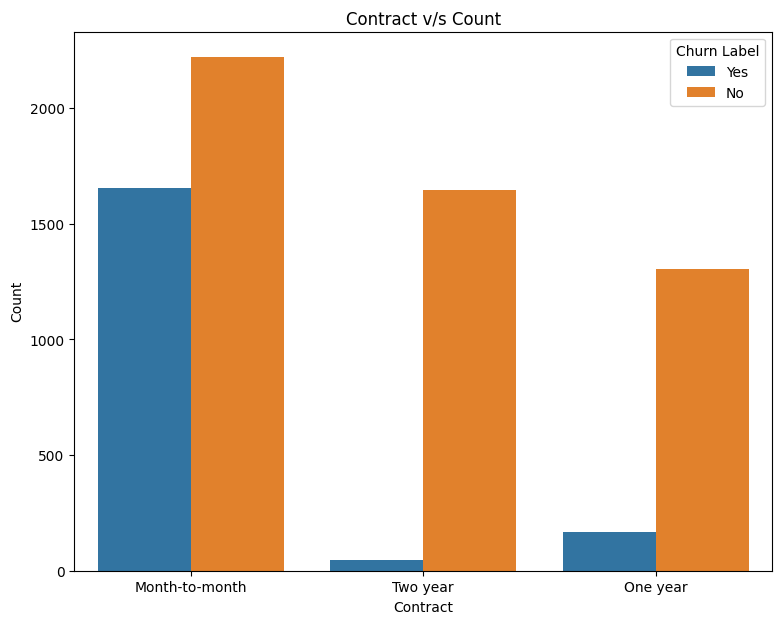

In [18]:
plt.figure( figsize = (9, 7) ) #height and width
sns.countplot( x = 'Contract', hue = 'Churn Label', data = df)
plt.xlabel('Contract')
plt.ylabel('Count')
plt.title('Contract v/s Count')
plt.show()

In [19]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

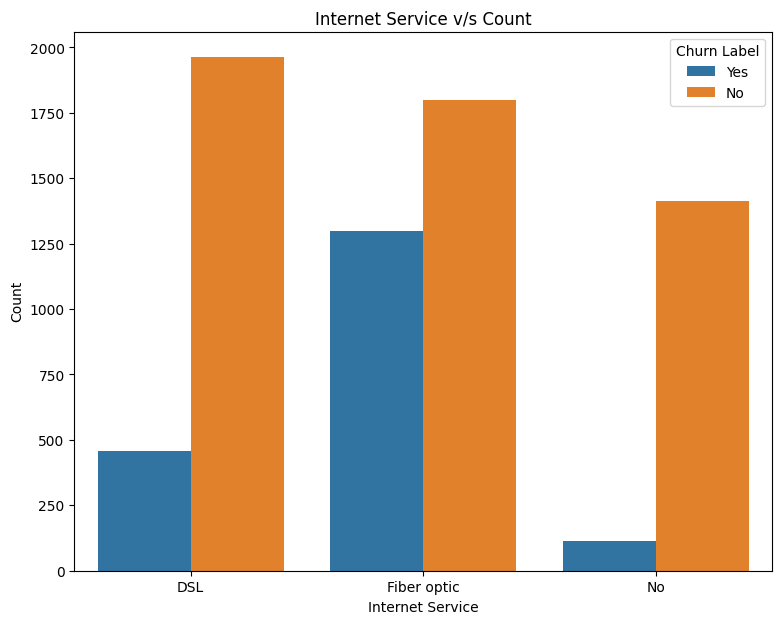

In [20]:
plt.figure( figsize = (9, 7) ) #height and width
sns.countplot( x = 'Internet Service', hue = 'Churn Label', data = df)
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.title('Internet Service v/s Count')
plt.show()

In [21]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [22]:
df['Payment Method'].value_counts()

,count
Payment Method,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


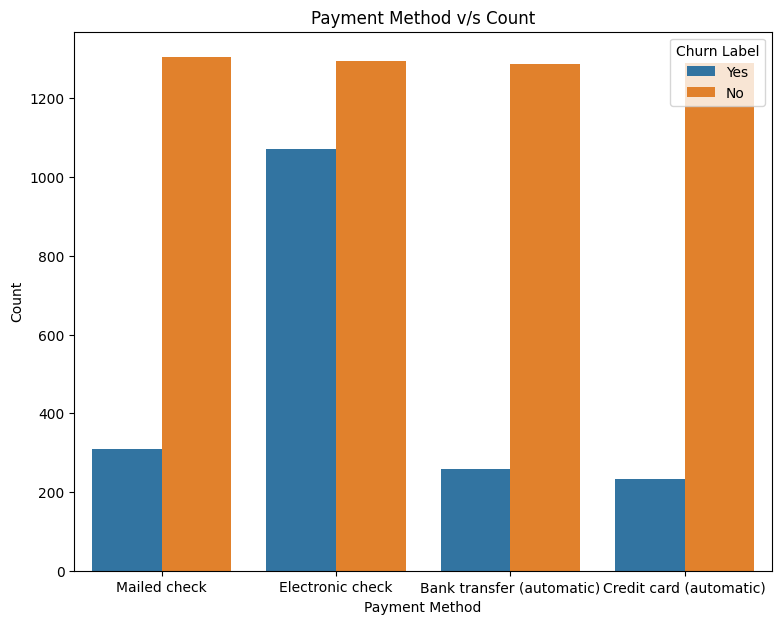

In [23]:
plt.figure( figsize = (9, 7) ) #height and width
sns.countplot( x = 'Payment Method', hue = 'Churn Label', data = df)
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.title('Payment Method v/s Count')
plt.show()

In [24]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [25]:
df['Tech Support'].value_counts()

,count
Tech Support,
No,3473
Yes,2044
No internet service,1526


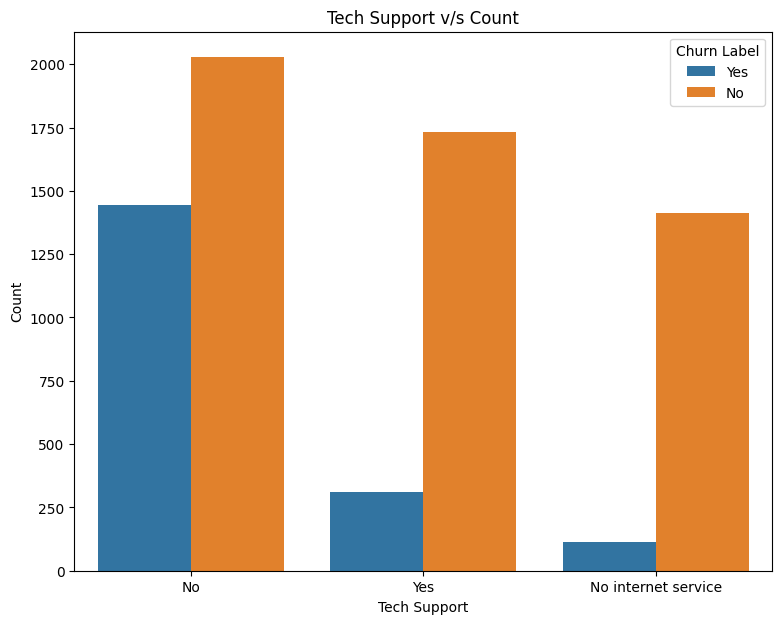

In [26]:
plt.figure( figsize = (9, 7) ) #height and width
sns.countplot( x = 'Tech Support', hue = 'Churn Label', data = df)
plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.title('Tech Support v/s Count')
plt.show()

In [27]:
avg_tenure=df.groupby("Churn Label")['Tenure Months'].mean()

In [28]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [30]:
numerical_cols=['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']

In [31]:
correlation_matrix=df[numerical_cols].corr()

In [32]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [33]:
from matplotlib.colors import Normalize
contract_churn=pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [34]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [36]:
#Data Cleaning

In [37]:
##Check Total Changes:

In [38]:
print(df['Total Charges'].dtype)



object


In [39]:
display(df['Total Charges'].head())

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3


In [40]:
##Convert Datatypes:

In [41]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [43]:
##Check Missing Values:

In [44]:
print(df['Total Charges'].isnull().sum())

11


In [45]:
##View Affected Records:

In [46]:
df[df['Total Charges'].isnull()]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


In [47]:
##Fill Missing Values:

In [48]:
df['Total Charges'] = df['Total Charges'].fillna(
    df['Total Charges'].median())

In [49]:
print(df['Total Charges'].isnull().sum())

0


In [50]:
##Verify DataSet:

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [52]:
#Feature Selection

In [53]:
columns_to_remove = ['CustomerID','Count','Country','State','City','Zip Code','Lat Long','Latitude','Longitude','Churn Label','Churn Score','CLTV','Churn Reason']

In [54]:
df = df.drop(columns=columns_to_remove)

In [55]:
print(df.shape)

(7043, 20)


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [57]:
#Encoding Categorial Features

In [58]:
##Machine Learning Requires Numerical Data:

In [59]:
df_encoded = pd.get_dummies(df,drop_first=True)

In [60]:
##Check Transformed Dataset

In [61]:
print("Original Shape:")
print(df.shape)

Original Shape:
(7043, 20)


In [62]:
print("Encoded Shape:")
print(df_encoded.shape)

Encoded Shape:
(7043, 31)


In [63]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [64]:
#Train -Test Split

In [65]:
## Separate Features and Target:

In [66]:
x = df_encoded.drop('Churn Value',axis=1)

In [67]:
y = df_encoded['Churn Value']

In [68]:
print(x.shape)

(7043, 30)


In [69]:
print(y.shape)

(7043,)


In [70]:
## Split DataSet:

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [73]:
print(x_train.shape)

(5634, 30)


In [74]:
print(x_test.shape)

(1409, 30)


In [75]:
#Random Forest Implementation

In [76]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,recall_score,precision_score,f1_score)

In [78]:
rf = RandomForestClassifier(n_estimators=150,criterion='entropy',random_state=42)
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)

In [79]:
##Evalute:

In [80]:
rf_balanced = RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42)

rf_balanced.fit(x_train,y_train)

balanced_pred = rf_balanced.predict(x_test)

In [81]:
print(classification_report(y_test,balanced_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.68      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [82]:
#Handle Class imbalance

In [83]:
rf_balanced = RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42)
rf_balanced.fit(x_train,y_train)
balanced_pred = rf_balanced.predict(x_test)
print(classification_report(y_test,balanced_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.68      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [84]:
#Hyperparameter Tuning

In [85]:
from sklearn.metrics import recall_score
results = []
for trees in [100,200,300,400]:
    for depth in [5,10,15]:
        model = RandomForestClassifier(n_estimators=trees,max_depth=depth,class_weight='balanced',random_state=42)
        model.fit(x_train,y_train)
        prediction = model.predict(x_test)
        results.append([trees,depth,recall_score(y_test,prediction)])
result_df = pd.DataFrame(results,columns=['Trees','Depth','Recall'])
result_df.sort_values(by='Recall',ascending=False)

,Trees,Depth,Recall
6,300,5,0.8200
0,100,5,0.8150
9,400,5,0.8125
3,200,5,0.8125
7,300,10,0.7450
10,400,10,0.7425
4,200,10,0.7400
1,100,10,0.7400
11,400,15,0.6325
5,200,15,0.6300


In [86]:
#Feature Importance Analysis

In [87]:
importance_df = pd.DataFrame({'Feature':x.columns,'Importance':rf_balanced.feature_importances_})
importance_df = importance_df.sort_values(by='Importance',ascending=False)
importance_df.head(15)

,Feature,Importance
0,Tenure Months,0.170552
2,Total Charges,0.170428
1,Monthly Charges,0.146499
25,Contract_Two year,0.058741
6,Dependents_Yes,0.046336
10,Internet Service_Fiber optic,0.037868
28,Payment Method_Electronic check,0.036512
24,Contract_One year,0.026752
13,Online Security_Yes,0.025626
3,Gender_Male,0.024668


In [88]:
#Visuliazation

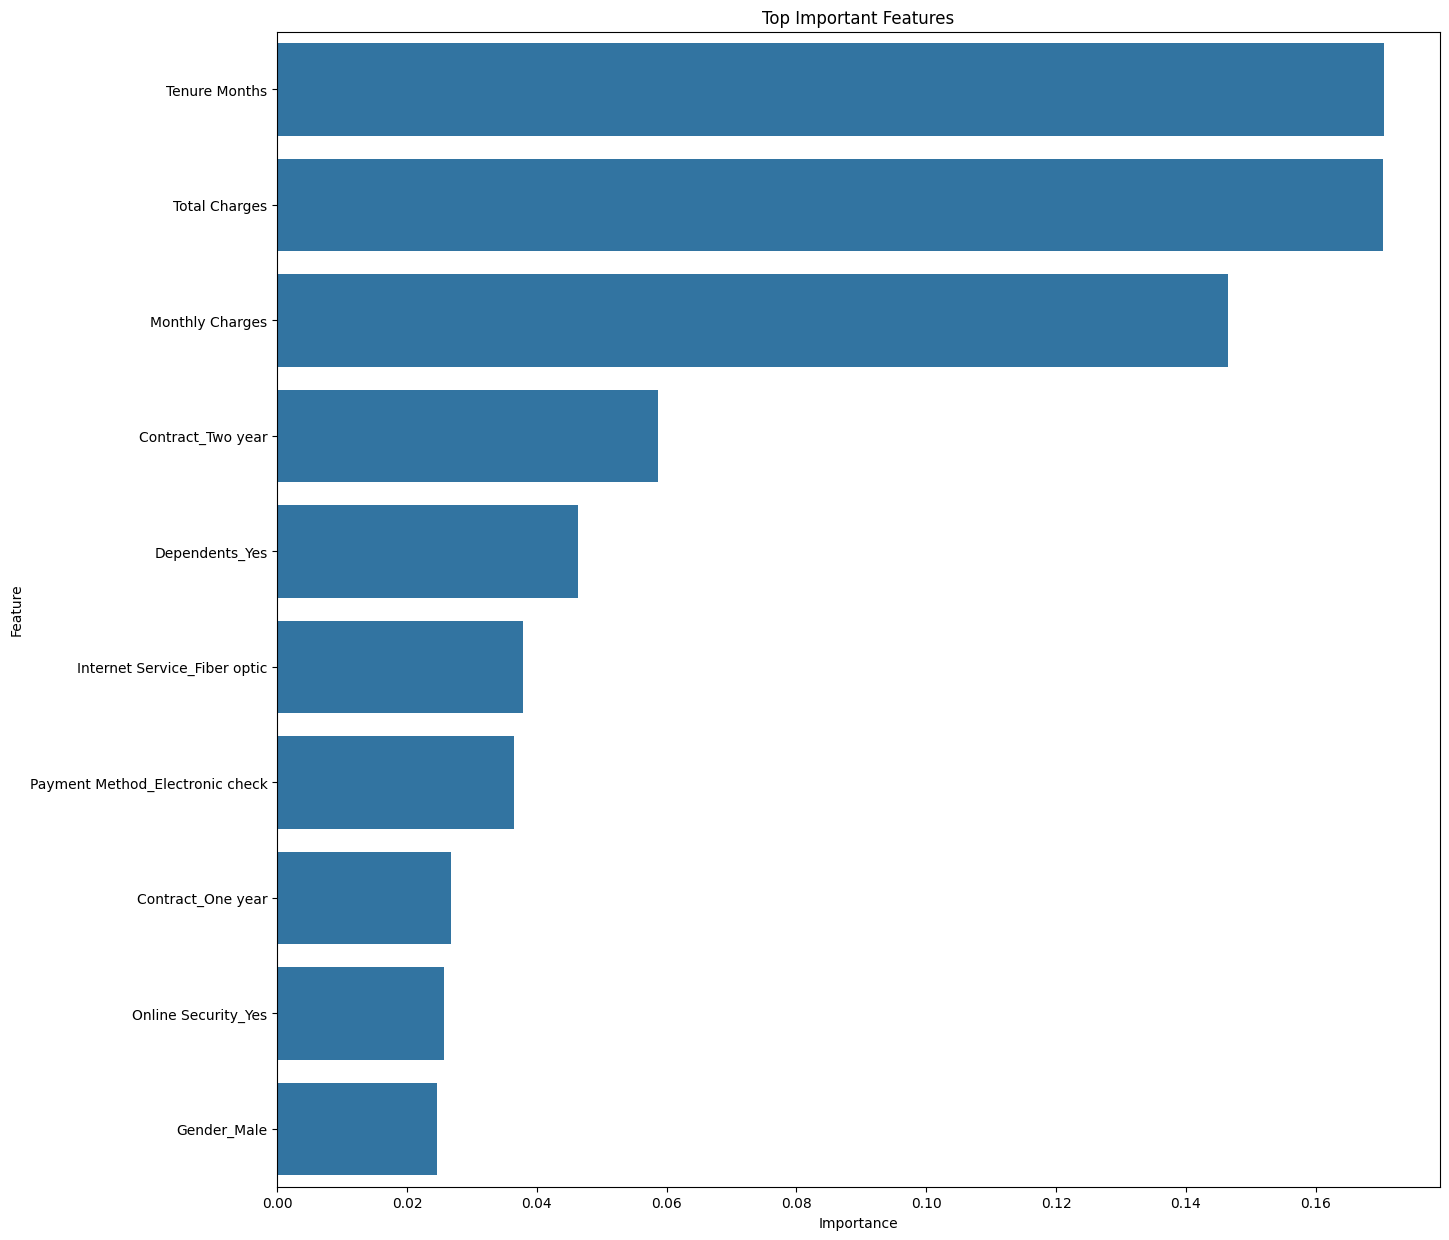

In [89]:
plt.figure(figsize=(15,15))
sns.barplot(data=importance_df.head(10),x='Importance',y='Feature')
plt.title("Top Important Features")
plt.show()

In [90]:
#Cross Validation

In [91]:
from sklearn.model_selection import cross_val_score

In [92]:
final_model = RandomForestClassifier(n_estimators=300,max_depth=10,class_weight='balanced',random_state=42)
cv_accuracy = cross_val_score(final_model,x,y,cv=5,scoring='accuracy')
print(cv_accuracy)

[0.76792051 0.79985806 0.75869411 0.78622159 0.78622159]


In [93]:
print(cv_accuracy.mean())

0.7797831714949351


In [94]:
# ROC-AUC Evalution

In [95]:
from sklearn.metrics import (roc_curve,roc_auc_score)

In [96]:
probabilities = rf_balanced.predict_proba(x_test)
churn_probability = probabilities[:,1]
fpr,tpr,threshold = roc_curve(y_test,churn_probability)
auc_score = roc_auc_score(y_test,churn_probability)
print("AUC Score:",auc_score)

AUC Score: 0.8381912784935579


In [97]:
##plot:

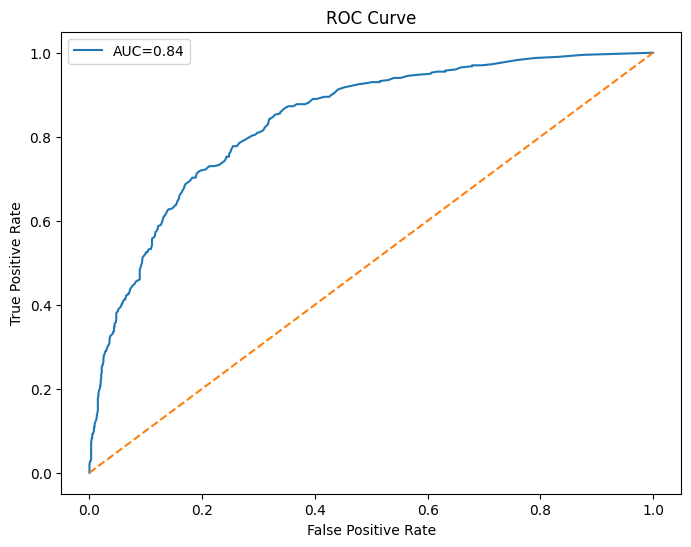

In [98]:
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"AUC={auc_score:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [99]:
#Customer Segmentation

In [100]:
## Create Segmentation DataSet:

In [101]:
segment_df = pd.DataFrame({'Tenure Months':x_test['Tenure Months'],'Monthly Charges':x_test['Monthly Charges'],'Total Charges':x_test['Total Charges'],'Churn Probability':churn_probability})
segment_df.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
185,15,85.9,1269.55,0.34500
2715,18,56.8,1074.65,0.20500
3825,2,20.0,40.90,0.03925
1807,6,84.2,519.15,0.65500
132,40,104.8,4131.95,0.33500


In [102]:
#Standardization

In [103]:
from sklearn.preprocessing import StandardScaler

In [104]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(segment_df)

In [105]:
#Elbow Method

In [106]:
from sklearn.cluster import KMeans

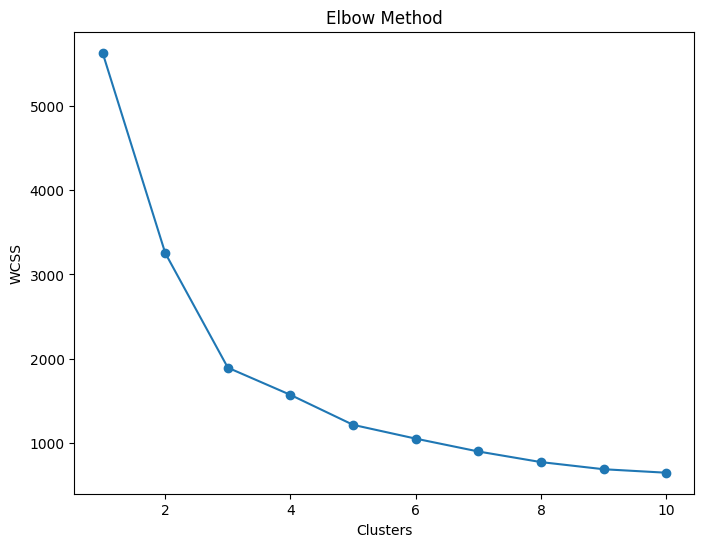

In [107]:
wcss=[]
for k in range(1,11):
    model = KMeans(n_clusters=k,random_state=42)
    model.fit(scaled_data)
    wcss.append(model.inertia_)
plt.figure(figsize=(8,6))
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [108]:
#K-Means Clustering

In [109]:
kmeans = KMeans(n_clusters=3,random_state=42)
segment_df['Cluster'] = kmeans.fit_predict(scaled_data)
segment_df.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
185,15,85.9,1269.55,0.34500,0
2715,18,56.8,1074.65,0.20500,1
3825,2,20.0,40.90,0.03925,1
1807,6,84.2,519.15,0.65500,0
132,40,104.8,4131.95,0.33500,2


In [110]:
##Cluster Names:

In [111]:
cluster_names = {0:'Budget Loyal Customers',1:'High Risk New Customers',2:'Loyal Premium Customers'}
segment_df['Cluster Segment'] = (segment_df['Cluster'].map(cluster_names))

In [112]:
#Cluster Visualization

In [113]:
##Montly Charges:

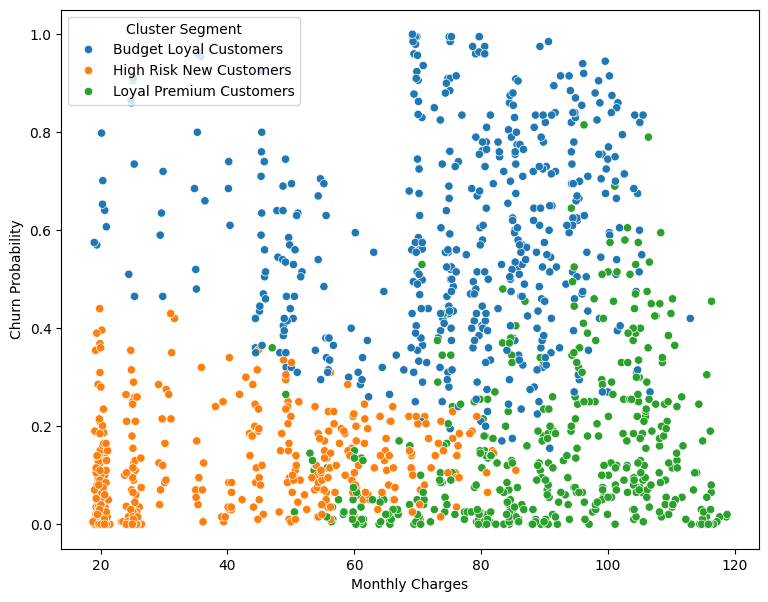

In [114]:
plt.figure(figsize=(9,7))
sns.scatterplot(x='Monthly Charges',y='Churn Probability',hue='Cluster Segment',data=segment_df)
plt.show()

In [115]:
##Tenuture Months:

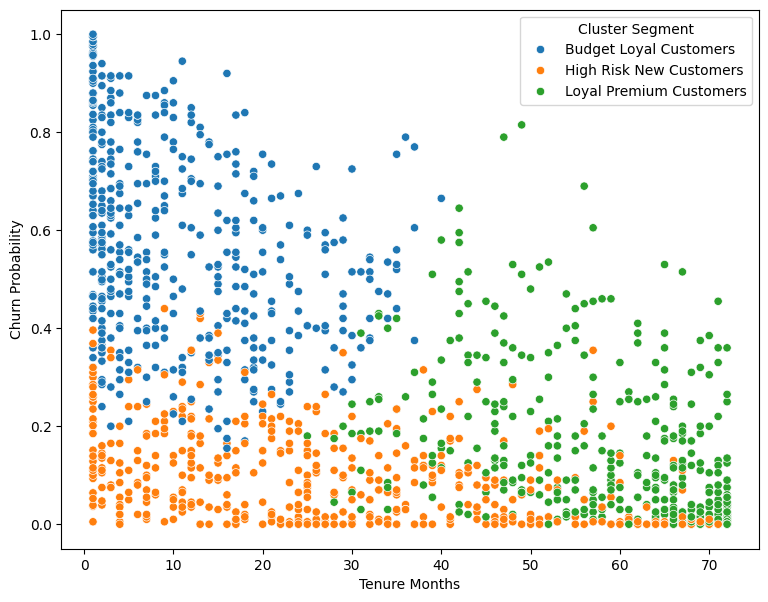

In [116]:
plt.figure(figsize=(9,7))
sns.scatterplot(x='Tenure Months',y='Churn Probability',hue='Cluster Segment',data=segment_df)
plt.show()

In [117]:
##Total Charges"

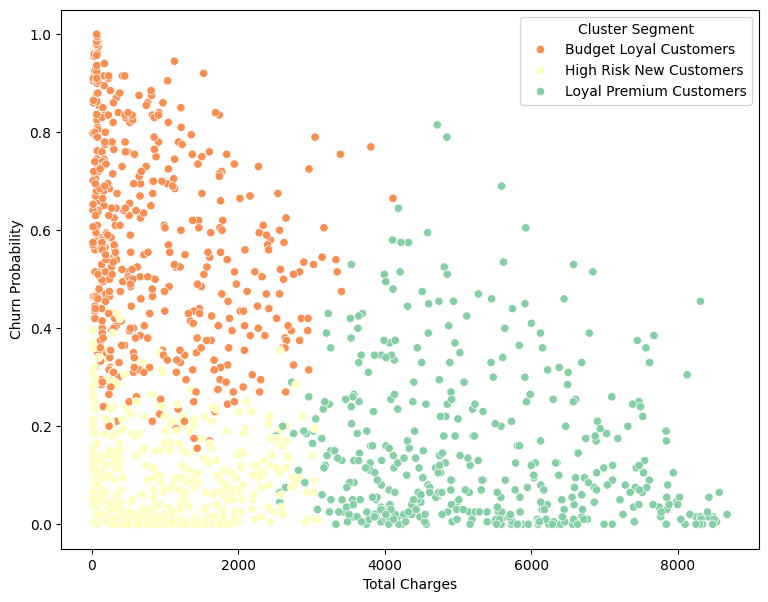

In [118]:
plt.figure(figsize=(9,7))
sns.scatterplot(x='Total Charges',y='Churn Probability',hue='Cluster Segment',data=segment_df,palette='Spectral')
plt.show()